# Tabular Models 1-4 — Training DFs and CV Comparison

Each row of the focal-perspective snapshot table is one
`(match, joint-stable segment, focal-team perspective)` observation. The
four tabular models differ only in which columns they project off that
table:

| Model | Personnel | Opponent in view? | Feature count |
|---|---|---|---|
| `tab_pos_ego` | raw positions | no | 13 |
| `tab_pos_matchup` | raw positions | yes | 25 |
| `tab_arch_ego` | per-season archetypes | no | 13 |
| `tab_arch_matchup` | per-season archetypes | yes | 25 |

All four share the same XGBoost regressor, the same target
(`xg_team1_minus_team2_per_30`), and the same 5-fold CV harness blocked
by `match_id`. Comparison isolates the marginal contribution of
(a) archetype enrichment and (b) opponent conditioning under tabular
structure.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import tab_pos_ego, tab_pos_matchup, tab_arch_ego, tab_arch_matchup

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 220)

snaps = pd.read_parquet(ROOT / 'data' / 'processed' / 'lineup_snapshots.parquet')
print('snapshot table:', snaps.shape)
MODELS = [tab_pos_ego, tab_pos_matchup, tab_arch_ego, tab_arch_matchup]

snapshot table: (79782, 92)


## Training DataFrame per model

Each model's `build_features` selects its columns off the snapshot table
and casts the categorical features to `category` dtype so XGBoost's
native categorical handling kicks in. The `y` and `groups` returned
alongside `X` are identical across the four models — only `X` changes.

In [2]:
X, y, groups = tab_pos_ego.build_features(snaps)
print(f'tab_pos_ego \u2014 X shape: {X.shape}, target: {y.name}')
print('feature columns:', list(X.columns))
X.head(3)

tab_pos_ego — X shape: (79782, 13), target: xg_team1_minus_team2_per_30
feature columns: ['team1_formation', 'team1_position_1', 'team1_position_2', 'team1_position_3', 'team1_position_4', 'team1_position_5', 'team1_position_6', 'team1_position_7', 'team1_position_8', 'team1_position_9', 'team1_position_10', 'team1_position_11', 'team1_is_home']


,team1_formation,team1_position_1,team1_position_2,team1_position_3,team1_position_4,team1_position_5,team1_position_6,team1_position_7,team1_position_8,team1_position_9,team1_position_10,team1_position_11,team1_is_home
0,4-4-2,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,1
1,4-4-2,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,1
2,4-4-2,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,1


In [3]:
X, y, groups = tab_pos_matchup.build_features(snaps)
print(f'tab_pos_matchup \u2014 X shape: {X.shape}, target: {y.name}')
print('feature columns:', list(X.columns))
X.head(3)

tab_pos_matchup — X shape: (79782, 25), target: xg_team1_minus_team2_per_30
feature columns: ['team1_formation', 'team2_formation', 'team1_position_1', 'team1_position_2', 'team1_position_3', 'team1_position_4', 'team1_position_5', 'team1_position_6', 'team1_position_7', 'team1_position_8', 'team1_position_9', 'team1_position_10', 'team1_position_11', 'team2_position_1', 'team2_position_2', 'team2_position_3', 'team2_position_4', 'team2_position_5', 'team2_position_6', 'team2_position_7', 'team2_position_8', 'team2_position_9', 'team2_position_10', 'team2_position_11', 'team1_is_home']


,team1_formation,team2_formation,team1_position_1,team1_position_2,team1_position_3,team1_position_4,team1_position_5,team1_position_6,team1_position_7,team1_position_8,team1_position_9,team1_position_10,team1_position_11,team2_position_1,team2_position_2,team2_position_3,team2_position_4,team2_position_5,team2_position_6,team2_position_7,team2_position_8,team2_position_9,team2_position_10,team2_position_11,team1_is_home
0,4-4-2,4-4-1-1,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,CAM,LW,1
1,4-4-2,4-4-1-1,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,CAM,LW,1
2,4-4-2,4-4-1-1,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,SS,LW,GK,RB,LB,RCB,LCB,CM,RW,CM,ST,CAM,LW,1


In [4]:
X, y, groups = tab_arch_ego.build_features(snaps)
print(f'tab_arch_ego \u2014 X shape: {X.shape}, target: {y.name}')
print('feature columns:', list(X.columns))
X.head(3)

tab_arch_ego — X shape: (79782, 13), target: xg_team1_minus_team2_per_30
feature columns: ['team1_formation', 'team1_archetype_1', 'team1_archetype_2', 'team1_archetype_3', 'team1_archetype_4', 'team1_archetype_5', 'team1_archetype_6', 'team1_archetype_7', 'team1_archetype_8', 'team1_archetype_9', 'team1_archetype_10', 'team1_archetype_11', 'team1_is_home']


,team1_formation,team1_archetype_1,team1_archetype_2,team1_archetype_3,team1_archetype_4,team1_archetype_5,team1_archetype_6,team1_archetype_7,team1_archetype_8,team1_archetype_9,team1_archetype_10,team1_archetype_11,team1_is_home
0,4-4-2,GK-1,RWP-2,CD-0,RWD-2,CD-2,LWP-0,CM-2,CM-1,CM-3,CF-2,LWD-1,1
1,4-4-2,GK-1,RWP-2,CD-0,RWD-2,CD-2,CM-1,CM-2,LWP-0,CM-3,CF-1,LWD-1,1
2,4-4-2,GK-1,RWP-2,CD-0,RWD-2,CD-2,CM-2,CM-3,CM-1,CM-3,CF-1,LWD-1,1


In [5]:
X, y, groups = tab_arch_matchup.build_features(snaps)
print(f'tab_arch_matchup \u2014 X shape: {X.shape}, target: {y.name}')
print('feature columns:', list(X.columns))
X.head(3)

tab_arch_matchup — X shape: (79782, 25), target: xg_team1_minus_team2_per_30
feature columns: ['team1_formation', 'team2_formation', 'team1_archetype_1', 'team1_archetype_2', 'team1_archetype_3', 'team1_archetype_4', 'team1_archetype_5', 'team1_archetype_6', 'team1_archetype_7', 'team1_archetype_8', 'team1_archetype_9', 'team1_archetype_10', 'team1_archetype_11', 'team2_archetype_1', 'team2_archetype_2', 'team2_archetype_3', 'team2_archetype_4', 'team2_archetype_5', 'team2_archetype_6', 'team2_archetype_7', 'team2_archetype_8', 'team2_archetype_9', 'team2_archetype_10', 'team2_archetype_11', 'team1_is_home']


,team1_formation,team2_formation,team1_archetype_1,team1_archetype_2,team1_archetype_3,team1_archetype_4,team1_archetype_5,team1_archetype_6,team1_archetype_7,team1_archetype_8,team1_archetype_9,team1_archetype_10,team1_archetype_11,team2_archetype_1,team2_archetype_2,team2_archetype_3,team2_archetype_4,team2_archetype_5,team2_archetype_6,team2_archetype_7,team2_archetype_8,team2_archetype_9,team2_archetype_10,team2_archetype_11,team1_is_home
0,4-4-2,4-4-1-1,GK-1,RWP-2,CD-0,RWD-2,CD-2,LWP-0,CM-2,CM-1,CM-3,CF-2,LWD-1,GK-1,RWD-2,LWD-1,CD-2,CD-0,CM-2,RWP-0,CM-2,CF-1,CM-0,LWP-0,1
1,4-4-2,4-4-1-1,GK-1,RWP-2,CD-0,RWD-2,CD-2,CM-1,CM-2,LWP-0,CM-3,CF-1,LWD-1,GK-1,RWD-2,LWD-1,CD-2,CD-0,CM-2,RWP-0,CM-2,MISSING,CM-0,LWP-0,1
2,4-4-2,4-4-1-1,GK-1,RWP-2,CD-0,RWD-2,CD-2,CM-2,CM-3,CM-1,CM-3,CF-1,LWD-1,GK-1,RWD-2,LWD-1,CD-2,CD-0,CM-2,RWP-0,CM-2,MISSING,CM-0,LWP-0,1


## Cross-validated comparison

5-fold `GroupKFold` blocked by `match_id`. Both focal-perspective rows of
a given match share a `match_id` and therefore land in the same fold, so
the home / away mirror rows never straddle the train / test split.

Metrics:
- **MAE / RMSE** — regression error on `xg_team1_minus_team2_per_30`.
- **R²** — fraction of target variance explained.
- **Sign accuracy** — fraction of nonzero-target rows where the model
  correctly predicts which team out-created the other. Zero-target rows
  (segments with no shots by either team, ~16% of the data) are
  excluded since there's no correct direction.

Each model takes a few seconds per fold (500 boosted trees, ~64k train
rows) so the full sweep is a couple of minutes.

In [6]:
results = {}
for mod in MODELS:
    print(f'cross-validating {mod.NAME} ...', end=' ', flush=True)
    results[mod.NAME] = mod.cross_validate(snaps, n_splits=5)
    print('done')

cross-validating tab_pos_ego ... done
cross-validating tab_pos_matchup ... done
cross-validating tab_arch_ego ... done
cross-validating tab_arch_matchup ... done


In [7]:
rows = []
for name, metrics in results.items():
    rows.append({
        'model': name,
        'MAE (mean)':       metrics['mae'].mean(),
        'MAE (std)':        metrics['mae'].std(),
        'RMSE (mean)':      metrics['rmse'].mean(),
        'R\u00b2 (mean)':   metrics['r2'].mean(),
        'sign acc (mean)':  metrics['sign_acc'].mean(),
        'sign acc (std)':   metrics['sign_acc'].std(),
    })
summary = pd.DataFrame(rows).set_index('model').round(4)
summary

,MAE (mean),MAE (std),RMSE (mean),R² (mean),sign acc (mean),sign acc (std)
model,,,,,,
tab_pos_ego,0.5709,0.0126,1.0365,0.0140,0.5687,0.0065
tab_pos_matchup,0.5834,0.0130,1.0514,-0.0163,0.5653,0.0085
tab_arch_ego,0.5912,0.0104,1.0438,-0.0005,0.5678,0.0050
tab_arch_matchup,0.5844,0.0098,1.0292,0.0277,0.5908,0.0010


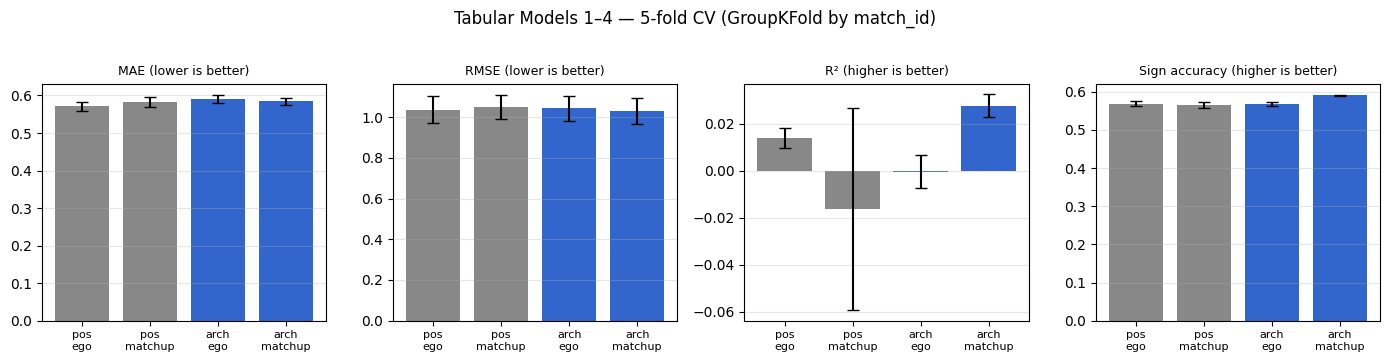

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=False)
metrics_to_plot = [
    ('mae', 'MAE (lower is better)', False),
    ('rmse', 'RMSE (lower is better)', False),
    ('r2', 'R\u00b2 (higher is better)', True),
    ('sign_acc', 'Sign accuracy (higher is better)', True),
]
model_names = [m.NAME for m in MODELS]
for ax, (key, title, _higher) in zip(axes, metrics_to_plot):
    means = [results[n][key].mean() for n in model_names]
    stds  = [results[n][key].std() for n in model_names]
    bars = ax.bar(range(len(model_names)), means, yerr=stds, capsize=4,
                  color=['#888', '#888', '#3366cc', '#3366cc'])
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.replace('tab_', '').replace('_', '\n') for n in model_names], fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Tabular Models 1\u20134 \u2014 5-fold CV (GroupKFold by match_id)', y=1.02)
fig.tight_layout(); plt.show()

## Pairwise comparisons

The 2 × 2 tabular grid lets us isolate each modeling-choice axis.

In [9]:
def delta(a, b, key):
    return results[b][key].mean() - results[a][key].mean()

comparisons = [
    ('opponent effect under raw positions',  'tab_pos_ego',  'tab_pos_matchup'),
    ('opponent effect under archetypes',     'tab_arch_ego', 'tab_arch_matchup'),
    ('archetype effect, ego perspective',    'tab_pos_ego',  'tab_arch_ego'),
    ('archetype effect, matchup perspective','tab_pos_matchup','tab_arch_matchup'),
    ('combined gain (Model 1 \u2192 Model 4)','tab_pos_ego', 'tab_arch_matchup'),
]
rows = []
for label, a, b in comparisons:
    rows.append({
        'comparison': label,
        'from': a, 'to': b,
        '\u0394 MAE':      delta(a, b, 'mae'),
        '\u0394 RMSE':     delta(a, b, 'rmse'),
        '\u0394 R\u00b2':  delta(a, b, 'r2'),
        '\u0394 sign acc': delta(a, b, 'sign_acc'),
    })
pd.DataFrame(rows).set_index('comparison').round(4)

,from,to,Δ MAE,Δ RMSE,Δ R²,Δ sign acc
comparison,,,,,,
opponent effect under raw positions,tab_pos_ego,tab_pos_matchup,0.0125,0.0148,-0.0302,-0.0034
opponent effect under archetypes,tab_arch_ego,tab_arch_matchup,-0.0068,-0.0146,0.0281,0.0229
"archetype effect, ego perspective",tab_pos_ego,tab_arch_ego,0.0203,0.0073,-0.0144,-0.0009
"archetype effect, matchup perspective",tab_pos_matchup,tab_arch_matchup,0.0010,-0.0222,0.0439,0.0255
combined gain (Model 1 → Model 4),tab_pos_ego,tab_arch_matchup,0.0135,-0.0073,0.0137,0.0221
